# Ajuste de Vogit en picos dQdV

In [2]:
from pathlib import Path
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.signal import savgol_filter
import func_deriv as func_deriv
import func_plots as func_plots
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.special import wofz

In [3]:
# %% ------- Cargar ciclos ------------------------------------------------------------
input_folder = Path('/home/mariajose/proc-icdv/tmp')
nombre_archivo = "NMC-20"
output_folder = Path('/home/mariajose/proc-icdv/output')
output_folder.mkdir(parents=True, exist_ok=True)  # Create output directory if it doesn't exist

with open(input_folder / f'{nombre_archivo}.json') as f_json:
    raw_dict = json.load(f_json)

dict_ciclos_sep = {
    int(ciclo): {
        etapa: pd.DataFrame(data) for etapa, data in etapas.items()
    }
    for ciclo, etapas in raw_dict.items()
}

indices_ciclos = list(dict_ciclos_sep.keys())

In [5]:
# %% ------- Elegir ciclos ------------------------------------------------------------

# Elijo en todo el rango, equiespaciados
N_ciclos = 10  # Número de ciclos a tomar, si no se especifica, toma todos los del archivo
indices_ciclos_ = indices_ciclos[:-1] # Quito el último
indices_ciclos_array = np.array(indices_ciclos_)
ciclos_disponibles = sorted(dict_ciclos_sep.keys())
ciclos_seleccionados = indices_ciclos_array[np.linspace(0, len(indices_ciclos_array)-1, N_ciclos, dtype=int)]
#print("Ciclos seleccionados:", ciclos_seleccionados)
#print(f"son {len(ciclos_seleccionados)} ciclos")

# Elecciones manuales
#ciclos_reducidos = [3, 21, 78, 153, 228, 303, 378, 453, 528, 603, 678, 753, 828]
#ciclos_seleccionados = [2, 99, 192, 300, 414, 504, 600, 702, 801, 897]
ciclos_seleccionados = [2, 21, 99, 198, 297, 396, 498, 597, 696, 795, 897]
ciclos_seleccionados = [21, 99, 198, 297, 396, 498, 597, 696, 795, 897]


excluir = {30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247} # ciclos feos
ciclos_seleccionados = [c for c in ciclos_disponibles if 21 <= c <= 300 and c not in excluir]

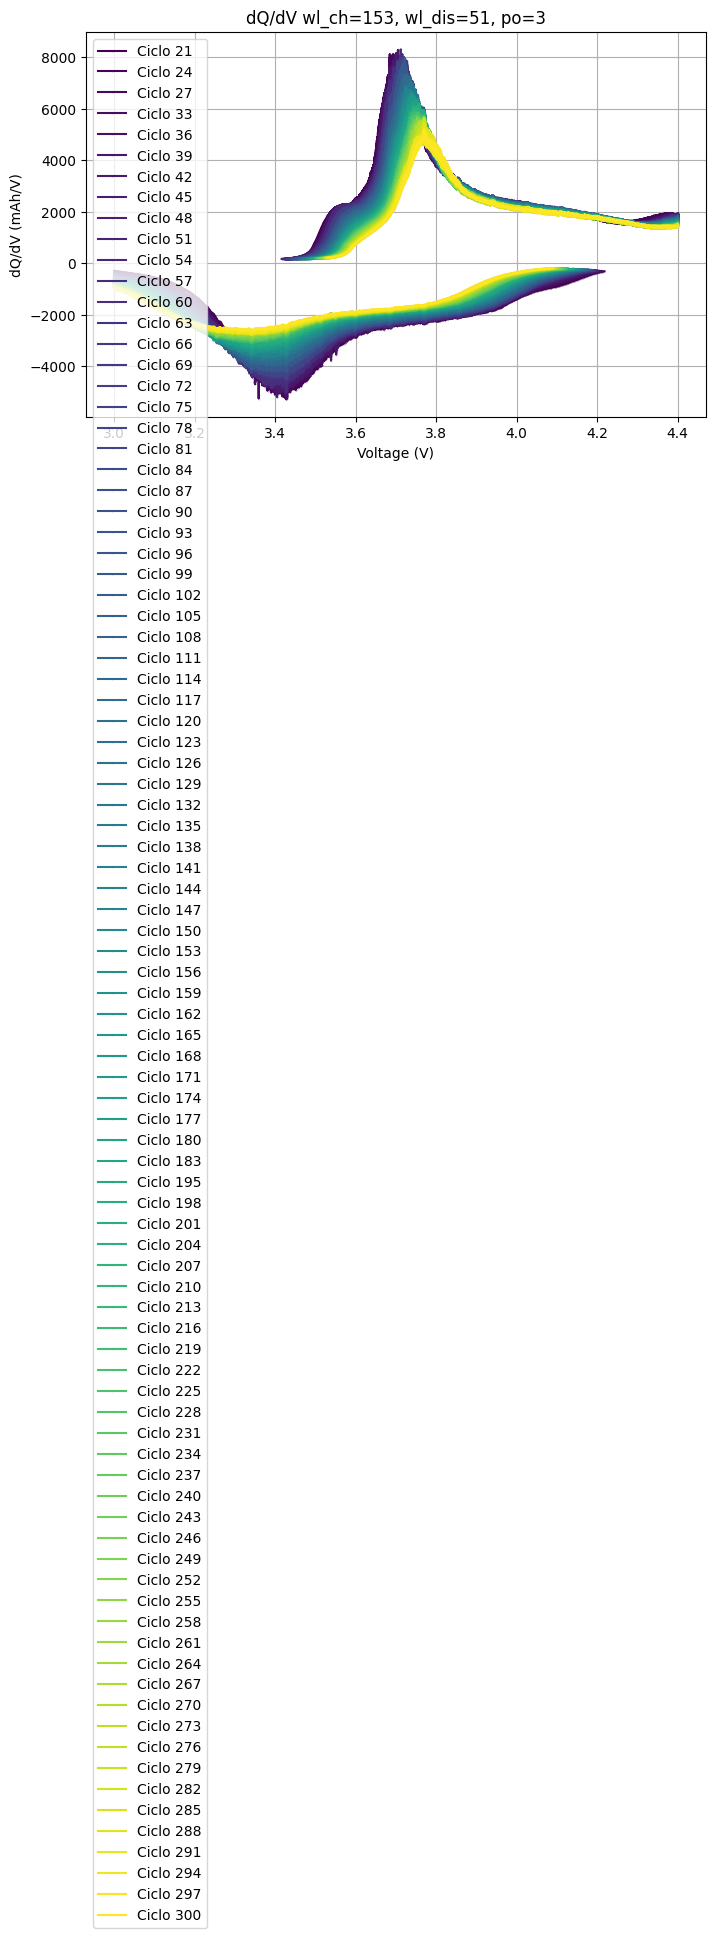

In [6]:
# %% ------- Trunco datos y calculo derivada ------------------------------------------------------------

# charge (wl = 153, truncar los n=30 puntos iniciales)
# discharge (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)

diccio = func_deriv.truncar_señal(ciclos_seleccionados, dict_ciclos_sep)
diccio =  func_deriv.plot_dqdv(ciclos_seleccionados, diccio)

In [8]:
# %% ------- Función Voigt ------------------------------------------------------------

def voigt(x, a, mu, sigma, gamma):
    """
    a: amplitud
    mu: centro
    sigma: ancho gaussiano
    gamma: ancho lorentziano
    """
    z = ((x - mu) + 1j*gamma) / (sigma * np.sqrt(2))
    return a * np.real(wofz(z)) / (sigma * np.sqrt(2*np.pi))

def multi_voigt(x, *params):
    """
    params: [a1, mu1, sigma1, gamma1, a2, mu2, sigma2, gamma2, ...]
    """
    y = np.zeros_like(x)
    for i in range(0, len(params), 4):
        a, mu, sigma, gamma = params[i:i+4]
        y += voigt(x, a, mu, sigma, gamma)
    return y

In [12]:
# %% ------- Parámetros iniciales ------------------------------------------------------------

# %% ------- Parámetros iniciales ------------------------------------------------------------

p_ini = [
    800, 3.55, 0.002,   # pico 1
    #1500, 3.61, 0.004,  # pico 2 (nuevo intermedio)
    3400, 3.69, 0.002,  # pico 3
    2900, 3.74, 0.013,  # pico 4
    1100, 4.0, 0.02,   # pico 5 (nuevo intermedio)
    2200, 4.39, 0.1    # pico 6
]

n_peaks = len(p_ini) // 3

# lower bounds (a > 0, sigma > 0, mu libre)
lb = []
ub = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    lb += [0, mu0-0.05, 1e-6]      # amplitud >=0, mu +- tolerancia, sigma > 0
    ub += [np.inf, mu0+0.05, np.inf]

bounds = (lb, ub)



# %% ------- Transformar parámetros iniciales -----------------------------------------
p_ini_voigt = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    gamma0 = sigma0   # gamma inicial igual a sigma
    p_ini_voigt += [a0, mu0, sigma0, gamma0]

# Bounds
lb_voigt = []
ub_voigt = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    gamma0 = sigma0
    lb_voigt += [0, mu0-0.05, 1e-6, 1e-6]
    ub_voigt += [np.inf, mu0+0.05, np.inf, np.inf]
bounds_voigt = (lb_voigt, ub_voigt)

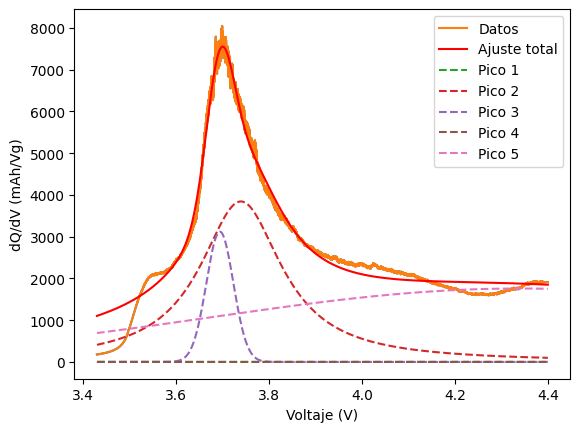

In [14]:
# %% ------- Ajuste ------------------------------------------------------------


df_ch = diccio[21]['Ch']
df_dis = diccio[21]['Dis']

dqdv_ch_calc = df_ch['dqdv_ch_calc']
V = df_ch['V_ch_savgol'] 

plt.plot(V, dqdv_ch_calc)


popt_voigt, pcov_voigt = curve_fit(multi_voigt, V, dqdv_ch_calc, p0=p_ini_voigt, bounds=bounds_voigt)

# Curva total ajustada
y_fit_voigt = multi_voigt(V, *popt_voigt)
plt.plot(V, dqdv_ch_calc, label="Datos")
plt.plot(V, y_fit_voigt, 'r-', label="Ajuste total")

# Dibujar cada pico Voigt individual
for i in range(0, len(popt_voigt), 4):
    a, mu, sigma, gamma = popt_voigt[i:i+4]
    plt.plot(V, voigt(V, a, mu, sigma, gamma), '--', label=f"Pico {i//4 + 1}")

plt.legend()
plt.xlabel("Voltaje (V)")
plt.ylabel("dQ/dV (mAh/Vg)")
plt.show()